In [1]:
import torch
import torchvision
import torch.nn as nn
import numpy as np
import torchvision.transforms as transforms
# https://github.com/yunjey/pytorch-tutorial/blob/master/tutorials/01-basics/pytorch_basics/main.py

f:\my_softers\project_IDE\Anconda\envs\jp_layout_pytorch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# =============================================== #
# 1.          Basic autograd example 1            # 
# =============================================== #

# Create tensors
x = torch.tensor(1., requires_grad=True)
w = torch.tensor(2., requires_grad=True)
b = torch.tensor(3., requires_grad=True)

# Build a computational graph
y = w * x + b

# Compute gradients.
y.backward()

# Print out the gradients.
print(x.grad.item()) 
print(w.grad.item())
print(b.grad.item())



2.0
1.0
1.0


In [18]:
# =============================================== #
# 2.          Basic autograd example 2            # 
# =============================================== #

# Create tensors of shape (10,3) and (10,2).
x = torch.rand(10,3)
y = torch.randn(10,2)

# Build a fully connected layer.
linear = nn.Linear(3, 2)
print('linear.w:',linear.weight)
print('linear.b:',linear.bias)

# Build loss function an optimizer.
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(linear.parameters(), lr=0.01)

# Forward pass
pre = linear(x)

# Compute pass
loss = criterion(pre, y)
# Backward pass
loss.backward() 

print('loss: ',loss.item())
# Print out the gradients
print('linear.weight.grad:',linear.weight.grad)
print('linear.bias.grad:',linear.bias.grad)


print('='*6)
# 1-step gradient descent
optimizer.step()
# You can also perform gradient descent at the low level.
# linear.weight.data.sub_(0.01 * linear.weight.grad.data)
# linear.bias.data.sub_(0.01 * linear.bias.grad.data)


pre = linear(x)
loss = criterion(pre, y)
loss.backward() 

print('loss : ',loss.item())
print('linear.weight.grad:',linear.weight.grad)
print('linear.bias.grad:',linear.bias.grad)

linear.w: Parameter containing:
tensor([[-0.4528,  0.3615,  0.1206],
        [ 0.2752,  0.1003,  0.3904]], requires_grad=True)
linear.b: Parameter containing:
tensor([-0.3725,  0.2687], requires_grad=True)
loss:  0.9547465443611145
linear.weight.grad: tensor([[-0.2176, -0.2541, -0.2210],
        [ 0.5182,  0.5654,  0.5731]])
linear.bias.grad: tensor([-0.4086,  1.0130])
loss :  0.9322539567947388
linear.weight.grad: tensor([[-0.4313, -0.5036, -0.4376],
        [ 1.0268,  1.1195,  1.1358]])
linear.bias.grad: tensor([-0.8095,  2.0072])


In [19]:
# =============================================== #
# 3.          Loading data from numpy             # 
# =============================================== #
# Create a numpy array.
x = np.array([[1,2],[3,4]])

# numpy ---> tensor
y = torch.from_numpy(x)

# tensor ---> numpy
z = y.numpy()
print('y',y)
print('z',z)

y tensor([[1, 2],
        [3, 4]], dtype=torch.int32)
z [[1 2]
 [3 4]]


In [53]:
# =============================================== #
# 4.          Input pipeline                      # 
# =============================================== #
# Download and construct CIFAR-10 dataset.
train_dataset = torchvision.datasets.CIFAR10(root='data/',
                                         train=True,
                                         transform=transforms.ToTensor(),
                                         download=False
                                         )
# Fetch one data pair(read data from disk)
image, label = train_dataset[0]
print(image.size()) # torch.Size([3,32,32])
print(label)        # 6

# Data loader （this provids queues and threads in a very simple way).
train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset,
    batch_size=64,
    shuffle=True
)

#################### -----------only test begin-----------#######################
# Where iteration starts, queue and thread start to load data from files.
data_iter = iter(train_loader)
# Mini-batch images and labels.
images, labels = data_iter.next()
#################### -----------only test end-----------#######################

# Actual usage of the data loader is as below.
from images, labels in train_loader:
    # Training code should be written here.
    pass


torch.Size([3, 32, 32])
6


In [ ]:
# =============================================== #
# 5.    Input pipeline for custom dataset         # 
# =============================================== #
# You should build your custom dataset as below.
class CustomDataset(torch.utils.data.Dataset):
    def __init(self):
        # TODO
        # 1. Initialize file paths or a list of file names.
        pass
    def __getitem__(self, index):
        # TODO
        # 1. Read one data from file(e.g. using numpy.fromfile, PIL.Image.open).
        # 2. Preprocess the data (e.g. torchvision.Transform).
        # 3. Return a data pair(e.g. image and label).
        pass
    def __len__(self):
        # You should change 0 to total size of your dataset.
        return 0
 
 # You can then use the prebuilt data loader.
 custom_dataset = CustomDataset()
 train_loader = torch.utils.data.DataLoader(
                                            dataset = custom_dataset,
                                            batch_size=64,
                                            shuffle=True
                                            )

In [61]:
# =============================================== #
# 6.             Pretrained model                 # 
# =============================================== #
# Download and load the pretrained ResNet-18.
resnet = torchvision.models.resnet18(pretrained=True)
for para in resnet.parameters():
    para.requires_grad = False
resnet.fc = nn.Linear(resnet.fc.in_features,100) # example 将输出的1000分类修改为100分类

# Forward pass.
images = torch.randn(64,3,224,224)
out = resnet(images)
print(out.shape) # torch.Size([64, 100])


torch.Size([64, 100])


In [63]:
# =============================================== #
# 7.             Save and load the model          # 
# =============================================== #

# Save and load the entire model.
torch.save(resnet,'model/model.ckpt')
model = torch.load('model/model.ckpt')

# Save and load only the model parameters (recommended).
torch.save(resnet.state_dict(),'model/params.ckpt')
resnet.load_state_dict(torch.load('model/params.ckpt'))




<All keys matched successfully>

In [57]:
resnet

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [59]:
resnet.fc.in_features

512

In [55]:
no = 0
for i in train_loader:
    no += 1
    if no >10:
        break
    print(i)

[tensor([[[[0.5490, 0.5333, 0.5373,  ..., 0.3412, 0.3373, 0.3294],
          [0.5451, 0.5137, 0.5216,  ..., 0.5137, 0.5059, 0.5098],
          [0.5373, 0.5098, 0.4980,  ..., 0.5647, 0.5373, 0.5098],
          ...,
          [0.2392, 0.1961, 0.1765,  ..., 0.5451, 0.5412, 0.5451],
          [0.4000, 0.3569, 0.3255,  ..., 0.5529, 0.5490, 0.5412],
          [0.4824, 0.4745, 0.4667,  ..., 0.5412, 0.5451, 0.5412]],

         [[0.5176, 0.5137, 0.5216,  ..., 0.3569, 0.3608, 0.3608],
          [0.5176, 0.4941, 0.5098,  ..., 0.5294, 0.5137, 0.5059],
          [0.5137, 0.4980, 0.4941,  ..., 0.6000, 0.5569, 0.5137],
          ...,
          [0.2784, 0.2275, 0.2039,  ..., 0.5529, 0.5490, 0.5529],
          [0.4078, 0.3647, 0.3294,  ..., 0.5686, 0.5647, 0.5529],
          [0.4824, 0.4745, 0.4667,  ..., 0.5569, 0.5608, 0.5569]],

         [[0.4353, 0.4275, 0.4314,  ..., 0.3020, 0.2824, 0.2627],
          [0.4706, 0.4431, 0.4549,  ..., 0.5255, 0.5137, 0.5059],
          [0.4980, 0.4824, 0.4745,  ..., 

In [52]:
no = 0
for i in train_dataset:
    no += 1
    if no >10:
        break
    print(i)

(tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
         [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
         [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
         ...,
         [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
         [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
         [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],

        [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
         [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
         [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
         ...,
         [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
         [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
         [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],

        [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
         [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],
         [0.0824, 0.0000, 0.0314,  ..., 0.1961, 0.1961, 0

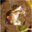

In [50]:
import cv2
from PIL import Image
a = image.transpose(0,-1).numpy()
a = np.around(a*255)
a = np.array(a,dtype=np.uint8)
Image.fromarray(a)
